In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, recall_score
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")

In [26]:
import pandas as pd
import numpy as np
import sqlite3
conn = sqlite3.connect(r"C:\Users\Admin\Desktop\3\ADY201m\data\clean\data_traffic_clean.db")
df = pd.read_sql("SELECT * FROM traffic_data_clean", conn)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Shape: (42226, 8)

Columns: ['id', 'timestamp', 'location', 'current_speed_kmh', 'free_flow_speed_kmh', 'speed_ratio', 'traffic_level', 'confidence']


,id,timestamp,location,current_speed_kmh,free_flow_speed_kmh,speed_ratio,traffic_level,confidence
0,1,2026-01-12 20:19:56,1,53.0,53.0,1.00,THOANG,1.000000
1,2,2026-01-12 20:19:56,2,39.0,49.0,0.80,DONG,0.990786
2,3,2026-01-12 20:19:56,3,29.0,38.0,0.76,DONG,0.914126
3,4,2026-01-12 20:19:56,4,29.0,39.0,0.74,DONG,0.940000
4,5,2026-01-12 20:19:56,5,30.0,39.0,0.77,DONG,0.928320


In [27]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek

le_location = LabelEncoder()
df['location'] = le_location.fit_transform(df['location'])

le_target = LabelEncoder()
df['traffic_level'] = le_target.fit_transform(df['traffic_level'])

df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if 7<=x<=9 or 17<=x<=19 else 0)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df.head()

,id,timestamp,location,current_speed_kmh,free_flow_speed_kmh,speed_ratio,traffic_level,confidence,hour,day_of_week,is_peak_hour,hour_sin,hour_cos
0,1,2026-01-12 20:19:56,0,53.0,53.0,1.00,2,1.000000,20,0,0,-0.866025,0.5
1,2,2026-01-12 20:19:56,11,39.0,49.0,0.80,0,0.990786,20,0,0,-0.866025,0.5
2,3,2026-01-12 20:19:56,18,29.0,38.0,0.76,0,0.914126,20,0,0,-0.866025,0.5
3,4,2026-01-12 20:19:56,19,29.0,39.0,0.74,0,0.940000,20,0,0,-0.866025,0.5
4,5,2026-01-12 20:19:56,20,30.0,39.0,0.77,0,0.928320,20,0,0,-0.866025,0.5


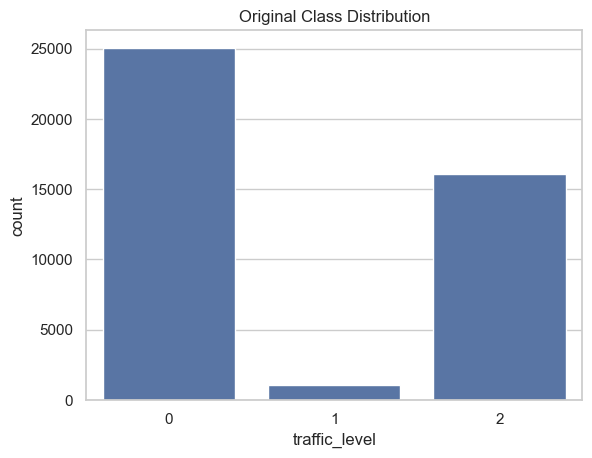

traffic_level
0    25053
2    16094
1     1079
Name: count, dtype: int64


In [28]:
sns.countplot(x=df['traffic_level'])
plt.title("Original Class Distribution")
plt.show()

print(df['traffic_level'].value_counts())

In [29]:
X = df[['location','hour_sin','hour_cos','is_peak_hour','day_of_week']]
y = df['traffic_level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Test distribution:")
print(y_test.value_counts())

Test distribution:
traffic_level
0    5011
2    3219
1     216
Name: count, dtype: int64


After SMOTE: [20042 20042 20042]


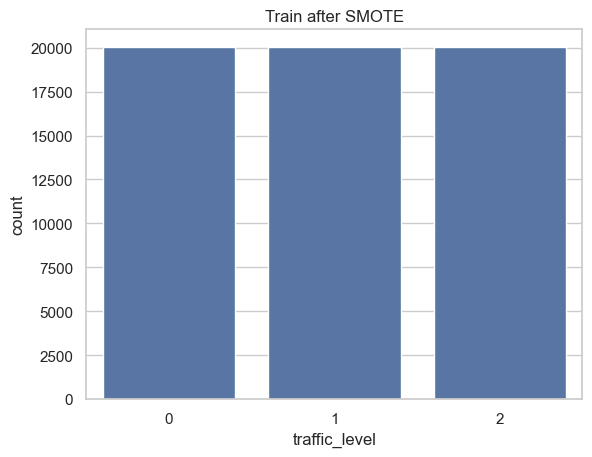

In [30]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

sns.countplot(x=y_train)
plt.title("Train after SMOTE")
plt.show()

Balanced test: [5011 5011 5011]


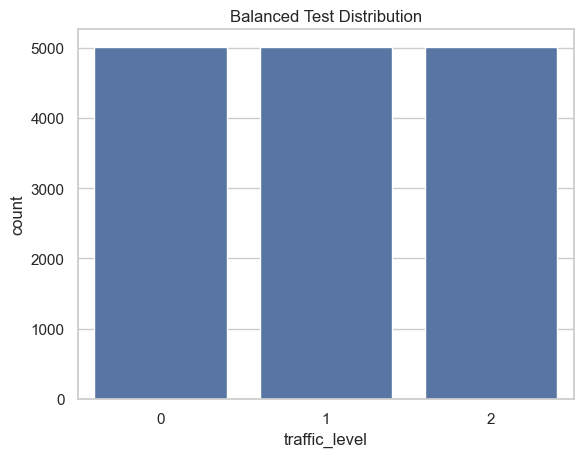

In [31]:
test_data = pd.concat([X_test, y_test], axis=1)

df_0 = test_data[test_data['traffic_level'] == 0]
df_1 = test_data[test_data['traffic_level'] == 1]
df_2 = test_data[test_data['traffic_level'] == 2]

max_size = max(len(df_0), len(df_1), len(df_2))

df_0_up = resample(df_0, replace=True, n_samples=max_size, random_state=42)
df_1_up = resample(df_1, replace=True, n_samples=max_size, random_state=42)
df_2_up = resample(df_2, replace=True, n_samples=max_size, random_state=42)

test_balanced = pd.concat([df_0_up, df_1_up, df_2_up]).sample(frac=1, random_state=42)

X_test_bal = test_balanced.drop('traffic_level', axis=1)
y_test_bal = test_balanced['traffic_level']

print("Balanced test:", np.bincount(y_test_bal))

sns.countplot(x=y_test_bal)
plt.title("Balanced Test Distribution")
plt.show()

In [32]:
log_model = LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced')
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'
)

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [33]:
y_pred_log = log_model.predict(X_test_bal)
y_pred_rf = rf_model.predict(X_test_bal)

print("=== Logistic Regression ===")
print(classification_report(y_test_bal, y_pred_log))

print("=== Random Forest ===")
print(classification_report(y_test_bal, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.50      0.26      0.34      5011
           1       0.47      0.55      0.51      5011
           2       0.51      0.66      0.58      5011

    accuracy                           0.49     15033
   macro avg       0.49      0.49      0.48     15033
weighted avg       0.49      0.49      0.48     15033

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.62      0.69      0.65      5011
           1       0.77      0.65      0.71      5011
           2       0.82      0.85      0.84      5011

    accuracy                           0.73     15033
   macro avg       0.74      0.73      0.73     15033
weighted avg       0.74      0.73      0.73     15033



In [34]:
print("=== TEST GỐC ===")
print("RF Accuracy:", accuracy_score(y_test, rf_model.predict(X_test)))

print("\n=== TEST BALANCED ===")
print("RF Accuracy:", accuracy_score(y_test_bal, y_pred_rf))

=== TEST GỐC ===
RF Accuracy: 0.7412976556950035

=== TEST BALANCED ===
RF Accuracy: 0.7322557041176079


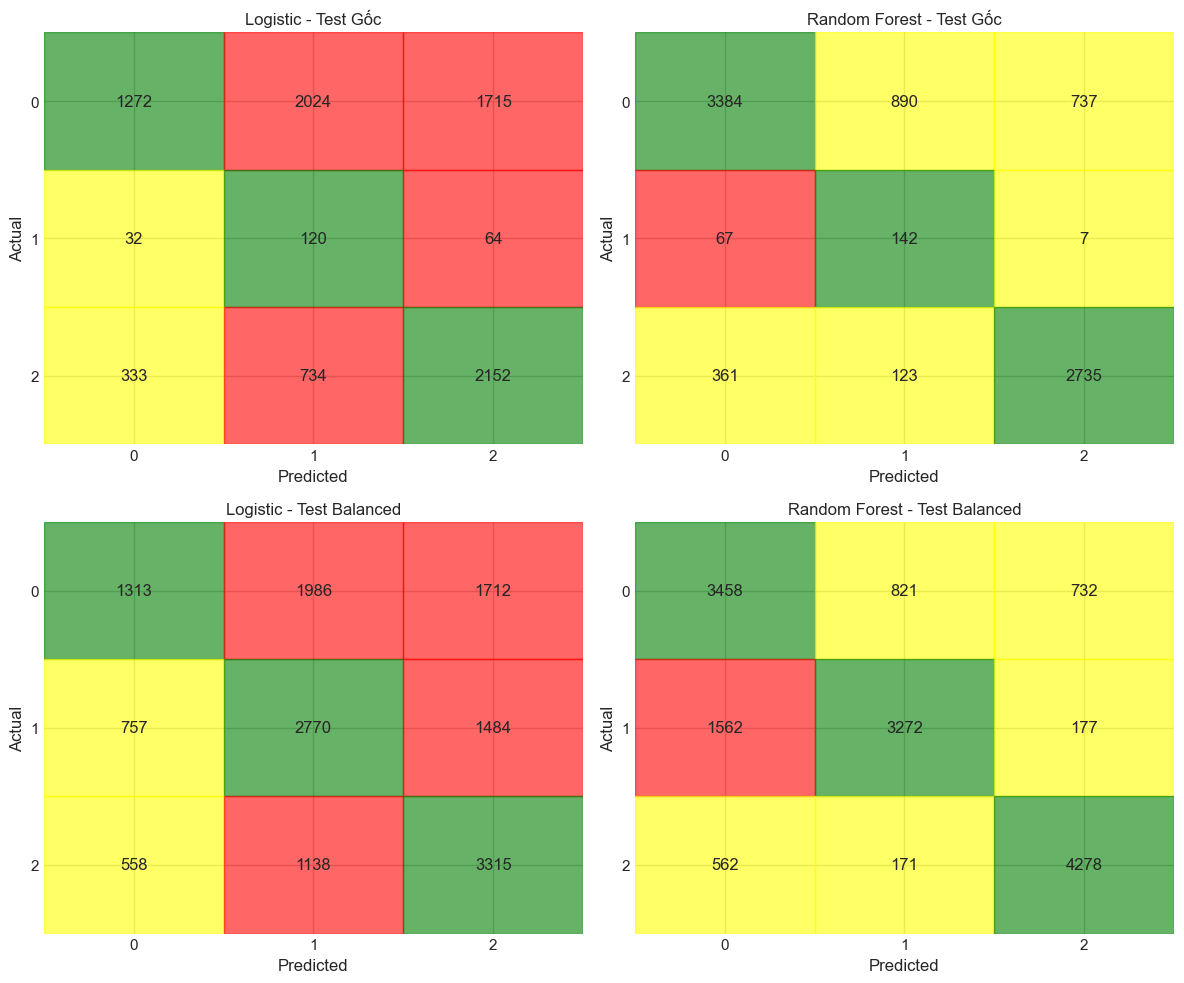

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_custom(cm, title, ax):
    cm = cm.astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ratio = cm_norm[i, j]

            if i == j:
                color = 'green'      # đúng
            elif ratio < 0.2:
                color = 'yellow'     # sai nhẹ
            else:
                color = 'red'        # sai nhiều

            rect = plt.Rectangle((j, i), 1, 1, color=color, alpha=0.6)
            ax.add_patch(rect)

            value = int(cm[i, j])
            ax.text(j + 0.5, i + 0.5, str(value),
                    ha='center', va='center', fontsize=12)

    ax.set_xlim(0, cm.shape[1])
    ax.set_ylim(0, cm.shape[0])

    ax.set_xticks(np.arange(cm.shape[1]) + 0.5)
    ax.set_yticks(np.arange(cm.shape[0]) + 0.5)

    ax.set_xticklabels(range(cm.shape[1]))
    ax.set_yticklabels(range(cm.shape[0]))
    ax.invert_yaxis()
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.tick_params(length=0)

# ================== CONFUSION MATRIX ==================

# ✅ TEST GỐC
cm_log_real = confusion_matrix(y_test, log_model.predict(X_test))
cm_rf_real = confusion_matrix(y_test, rf_model.predict(X_test))

# ✅ TEST BALANCED
cm_log_bal = confusion_matrix(y_test_bal, y_pred_log)
cm_rf_bal = confusion_matrix(y_test_bal, y_pred_rf)

# ================== PLOT ==================

fig, axes = plt.subplots(2, 2, figsize=(12,10))

plot_confusion_matrix_custom(cm_log_real, "Logistic - Test Gốc", axes[0,0])
plot_confusion_matrix_custom(cm_rf_real, "Random Forest - Test Gốc", axes[0,1])

plot_confusion_matrix_custom(cm_log_bal, "Logistic - Test Balanced", axes[1,0])
plot_confusion_matrix_custom(cm_rf_bal, "Random Forest - Test Balanced", axes[1,1])

plt.tight_layout()
plt.show()

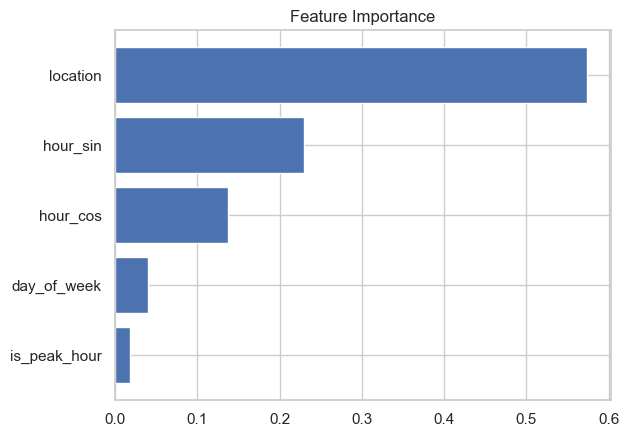

In [36]:
importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.barh(np.array(features)[indices], importances[indices])
plt.title("Feature Importance")
plt.show()

## 📌 Kết luận

### 1. Hiệu suất mô hình (Phân tích ma trận nhầm lẫn)

Ma trận nhầm lẫn được chuẩn hóa theo hàng, nghĩa là mỗi hàng đại diện cho tỷ lệ phần trăm dự đoán trong mỗi lớp thực tế.

- **Hồi quy Logistic** cho thấy hiệu suất hạn chế, với độ chính xác tổng thể là **49%**.

- Mô hình gặp khó khăn trong việc phân biệt giữa các lớp, đặc biệt là đối với **lớp 0** (độ thu hồi chỉ 26%).

- Mặc dù lớp 2 đạt được độ thu hồi cao hơn (66%), hiệu suất tổng thể vẫn không nhất quán.

- Điều này cho thấy Hồi quy Logistic quá đơn giản để nắm bắt các mẫu phức tạp trong dữ liệu giao thông.

- **Rừng ngẫu nhiên** vượt trội hơn đáng kể so với Hồi quy Logistic, đạt độ chính xác **73%**.
- **Lớp 2** được dự đoán rất tốt (độ chính xác 85%)

- **Lớp 1** cũng cho thấy hiệu suất mạnh mẽ (độ chính xác 77%)

- **Lớp 0** được dự đoán ở mức khá (độ chính xác 69%)

👉 Nhìn chung, thuật toán Rừng ngẫu nhiên cung cấp các dự đoán cân bằng và đáng tin cậy hơn trên tất cả các lớp, chứng tỏ khả năng mô hình hóa các mối quan hệ phi tuyến tính.

---

### 2. Phân tích tầm quan trọng của các đặc trưng

Kết quả phân tích tầm quan trọng của các đặc trưng cho thấy:

- **vị trí** là đặc trưng quan trọng nhất

- **ngày trong tuần** và **cos giờ** có ảnh hưởng vừa phải

- **giờ cao điểm** có tác động tối thiểu

👉 Điều này cho thấy:

- Tắc nghẽn giao thông phụ thuộc rất nhiều vào **vị trí cụ thể**

- Các mô hình liên quan đến thời gian rất quan trọng nhưng **phức tạp hơn các quy tắc giờ cao điểm đơn giản**
- Sử dụng các đặc trưng thời gian theo chu kỳ (sin/cos) hiệu quả hơn các chỉ báo giờ cao điểm nhị phân

---

### 3. Kết luận cuối cùng

- Tắc nghẽn giao thông bị ảnh hưởng bởi sự kết hợp của các yếu tố **không gian (vị trí)** và **thời gian (dựa trên thời gian)**

- Các mô hình tuyến tính đơn giản không đủ cho vấn đề này
- Các mô hình linh hoạt hơn như **Rừng ngẫu nhiên** phù hợp hơn để nắm bắt các mô hình phức tạp

---

### 4. Cải tiến trong tương lai

- Kết hợp thêm các đặc trưng như:

- Tốc độ thời gian thực

- Mật độ giao thông

- Điều kiện thời tiết
- Thử nghiệm với các mô hình nâng cao (ví dụ: Gradient Boosting, XGBoost)
- Áp dụng phương pháp kiểm định chéo để đánh giá mạnh mẽ hơn

---

### ✅ Tóm tắt

- Random Forest là mô hình hoạt động tốt nhất trong nghiên cứu này
- Kỹ thuật đặc trưng đóng vai trò quan trọng trong việc cải thiện hiệu suất
- Dự đoán lưu lượng giao thông đòi hỏi phải mô hình hóa cả hành vi **phụ thuộc vào vị trí** và **phụ thuộc vào thời gian**